In [992]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

%matplotlib inline

In [993]:
df = pd.read_csv('../data/Titanic_dataset.csv')
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [994]:
#1-- Handling missing values

In [995]:
# To see the no of missing values and which features have more missing values, 2 methods are there.. 

In [996]:
#M1

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [997]:
# Age feature has 177 missing values, while cabin has 687 and embarked has only 2.

<Axes: >

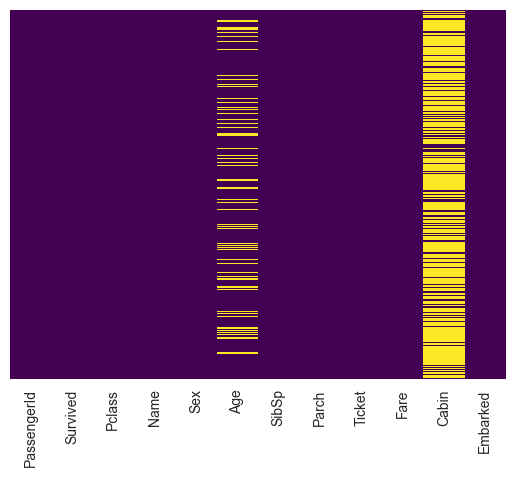

In [998]:
#M2--

sns.heatmap(df.isnull(), yticklabels= False, cbar = False, cmap= 'viridis')

In [999]:
#cbar = bar which shows the relation between colors on heatmap and numbers, cmap = color pallete(spectrum used)

#Since here the data is boolean we know 0 = purple, 1 = yellow so cbar not needed.

In [1000]:
# Missing value heatmap helps us to identify patterns like-- Whenever column A has a missing value, column B also as a missing value... etc..  
# Here, we observe that age feature has values--  missing completely at random (MCAR)

In [1001]:
#-- Also from both df.isnull().sum() its observed that age feature has less missing values which could be filled with mathematical calculations.
#-- But cabin feature has too many missing values so this feature might be dropped later or changed into -- cabin known(1 or 0)..

#Refer to the percentages calc in cell below-

In [1002]:
#Calculating the percentages of missing values in each feature.. 

missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent.sort_values(ascending= False)
print(missing_percent)

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


In [1003]:
#Analyzing the data and finding relations--

#1-- How many people survived?(countplot)
#2-- Relationship between passenger's gender and his/hers survival?(countplot with hue)
#3-- Which passenger class survived the most?(countplot with hue)
#4-- Age distribution of passengers?(displot with kde, displot without kde and histogram with matplotlib)
#5-- How many siblings/spouses were present? (countplot)
#6-- Fare distribution of passengers?(displot with kde)
#7-- How many passengers in each class?(countplot)

###--- Hue has been used with 1, 5 and 7 only to avoid the palette warning

In [1004]:
#1-- How many people survived?

<Axes: xlabel='Survived', ylabel='count'>

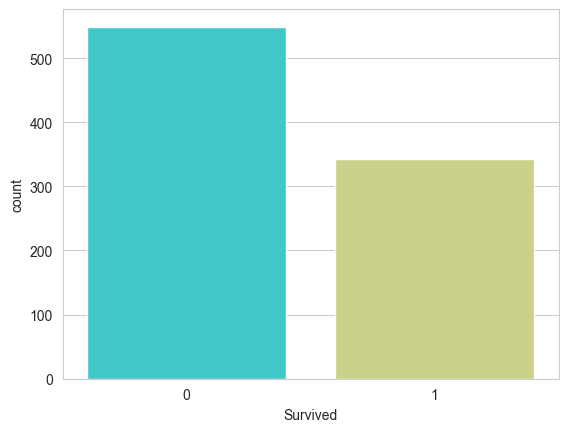

In [1005]:
sns.set_style('whitegrid')
sns.countplot(x = 'Survived', hue = 'Survived', legend = False, data = df, palette='rainbow')

In [1006]:
# Around 520 people died while around 320 survived.

In [1007]:
#2-- Relationship between passenger's gender and his/hers survival?

<Axes: xlabel='Survived', ylabel='count'>

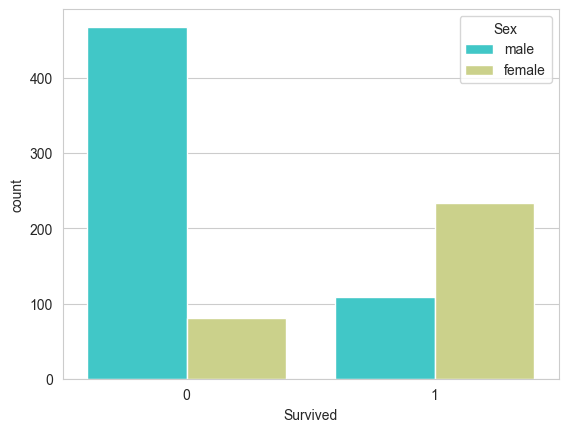

In [1008]:
sns.set_style('whitegrid')
sns.countplot(x= 'Survived', hue= 'Sex', palette='rainbow', data = df)

In [1009]:
# Majority of the people who died were males, which shows that females were given a higher priority than males for survival.

In [1010]:
#3-- Which passenger class survived the most?

#-- pclass = 1(rich), pclass = 3(poor), pclass = 2(in between)

<Axes: xlabel='Survived', ylabel='count'>

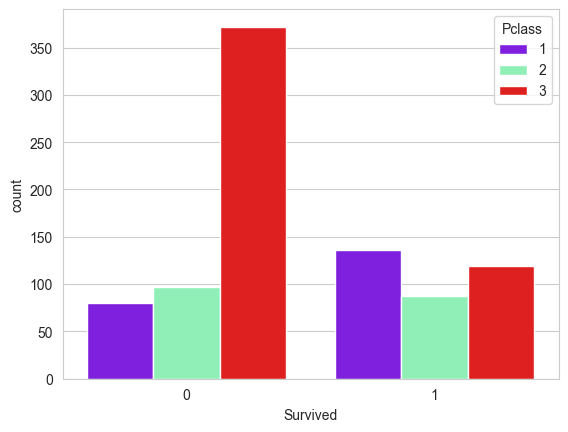

In [1011]:
sns.set_style('whitegrid')
sns.countplot(data= df, x = 'Survived', hue= 'Pclass', palette='rainbow')

In [1012]:
#-- Majority of people who died belonged to passenger class = 3. While majority of passenger class = 1 people survived.

In [1013]:
#4-- What was the age distribution of the passengers?

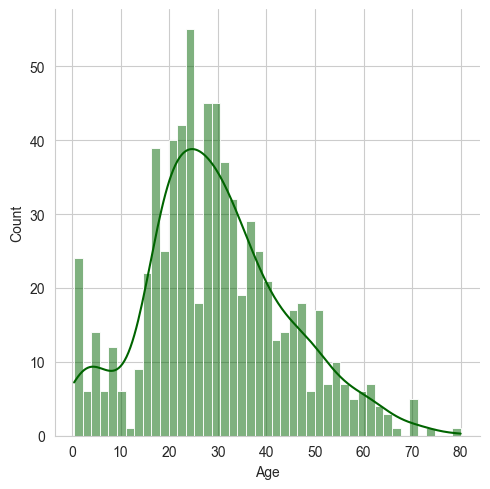

In [1014]:
sns.displot(df['Age'].dropna(), bins = 45, kde = True, color = 'darkgreen') #With kernal density estimation

#Kernal density estimation is used to form the probability density function.. 

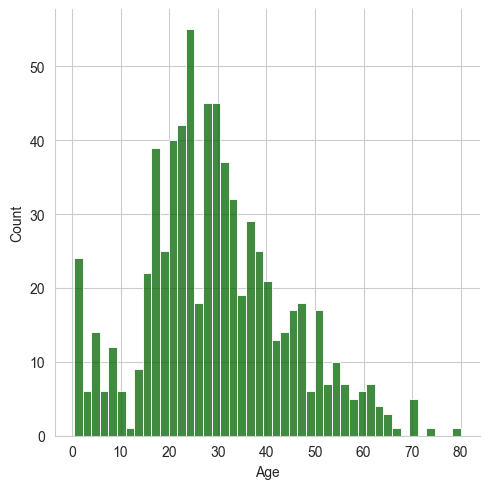

In [1015]:
sns.displot(df['Age'].dropna(), bins = 45, kde = False, color = 'darkgreen') #Without kernal density estimation

<Axes: >

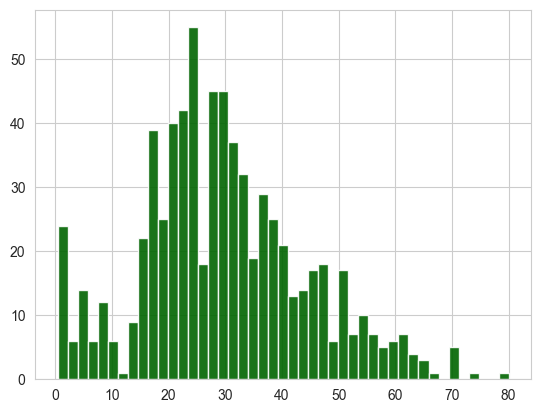

In [1016]:
#Forming the same age distribution histogram using matplotlib

df['Age'].hist(bins = 45, color= 'darkgreen', alpha = 0.9)

In [1017]:
# Majority of people = 20-40 years of age, there was also a spike in age distribution for children of age 0-3 years

<Axes: xlabel='SibSp', ylabel='count'>

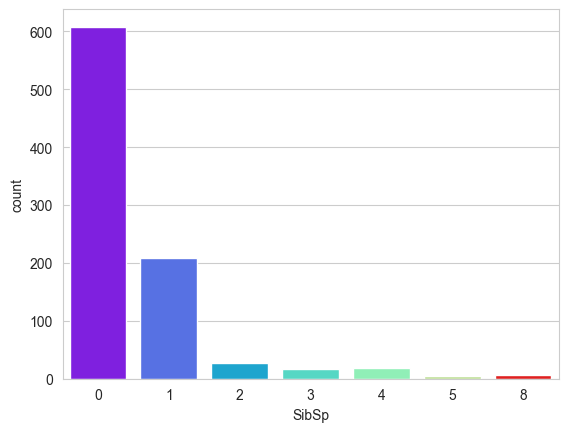

In [1018]:
# 5-- How many siblings/spouses were present?

sns.set_style('whitegrid')
sns.countplot(data= df, x= 'SibSp', hue = 'SibSp', legend = False, palette='rainbow')

In [1019]:
#-- Majority of passengers didnt have any siblings/spouse with them. 

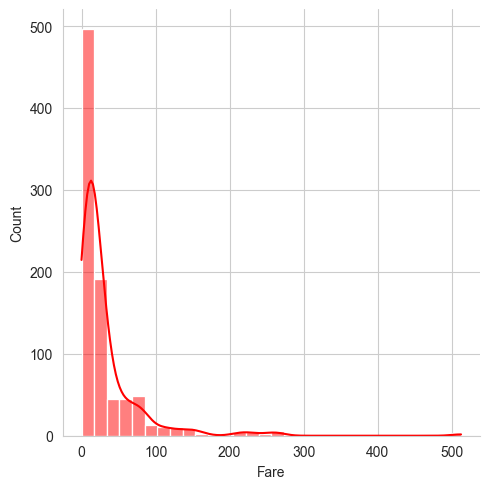

In [1020]:
#6-- Analyzing the fare paid by passengers for titanic. 

sns.displot(df['Fare'], bins = 30, kde= True, color = 'red')

In [1021]:
# Majority of passengers paid for cheap tickets and 3rd-class (see the next countplot to see how many passengers were there in each class)


#NOTE: Study and Add the outliers observation from above displot!

<Axes: xlabel='Pclass', ylabel='count'>

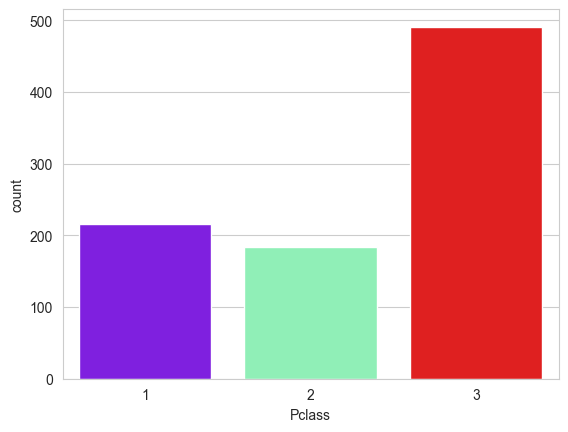

In [1022]:
#7-- How many passengers were there in each class?

sns.set_style('whitegrid')
sns.countplot(x= 'Pclass', hue = 'Pclass', data= df, palette='rainbow', legend = False)

In [1023]:
#Majority of passengers were in 3rd class and hence paid for cheaper tickets. 

In [1024]:
#### Handling missing values---

# Age, cabin and Embarked features had missing values.. 

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

<Axes: >

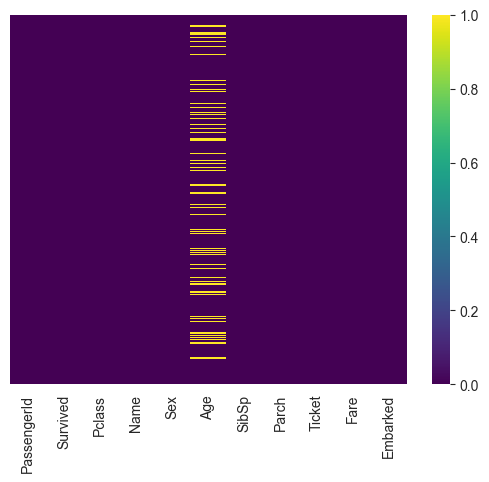

In [1025]:
# Handling missing values in cabin feature.. 

# When there are large no of missing values in a feature, then either drop that feature or apply feature engineering.. 


# Dropping cabin feature in this case.. 
df.drop('Cabin', inplace= True, axis = 1)

sns.heatmap(df.isnull(), yticklabels= False, cbar= True, cmap= 'viridis')

<Axes: xlabel='Pclass', ylabel='Age'>

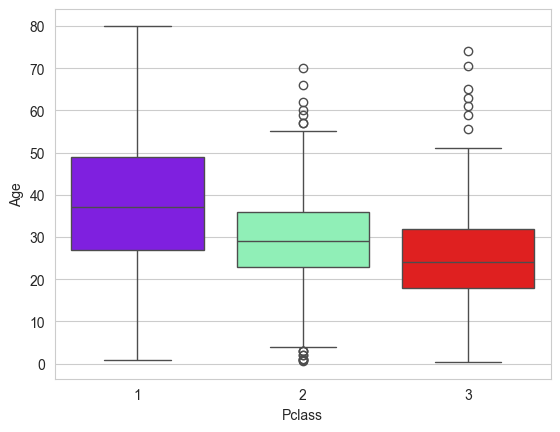

In [1026]:
# Handling the missing values in the age feature .. 

# M1 -- Drawing a boxplot, finding the approximate median age and filling it by applying a function .. [using Pclass feature along with age]

sns.boxplot(x = 'Pclass', hue= 'Pclass', y= 'Age', data = df, palette='rainbow', legend= False)

# Circles in boxplot = Outliers 

# Pclass = 1, approx median age = 37
# Pclass = 2, approx median age = 29
# Pclass = 3, approx median age = 24


<Axes: >

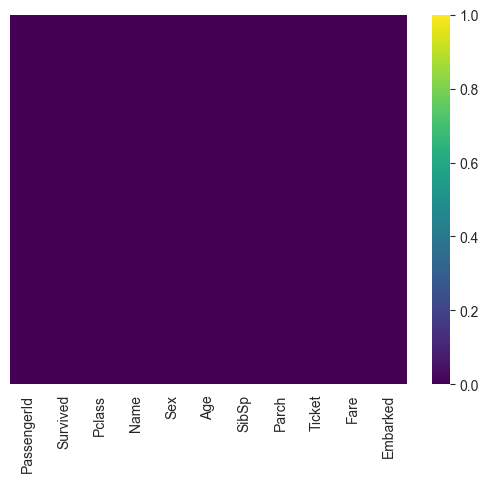

In [1027]:
#Function

def fill_median_age(features):

    Age = features['Age']
    Pclass = features['Pclass']

    if(pd.isnull(Age)):
        
        if(Pclass == 1):
            return 37
        elif(Pclass == 2):
            return 29
        else:
            return 24
    else:
        return Age

#Applying the function

df['Age'] = df[['Age', 'Pclass']].apply(fill_median_age, axis= 1)

sns.heatmap(df.isnull(), yticklabels= False, cbar= True, cmap= 'viridis')


In [1028]:
# This approach is better than filling the missing values with median age of entire age column... as this approach maintains feature correlation. 

In [1029]:
print(df.isnull().sum())

# Handling missing values in embarked feature..

#Since there are only 2 missing values, we can drop these 2 rows.. 

df.dropna(inplace= True)

# If handling of embarked was done before age then inside df.dropna also write subset = ['Embarked'] to avoid dropping rows with missing age. 

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64


In [1030]:
df.isnull().sum()

# All missing values have been handled

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [1031]:
# Converting categorical features into numbers so that model can understand them

df.info()

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    str    
 4   Sex          889 non-null    str    
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    str    
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 83.3 KB


In [1032]:
# Converting the sex and embarked features.. 

Sex = pd.get_dummies(df['Sex'], drop_first=True)
Embarked = pd.get_dummies(df['Embarked'], drop_first=True)

#drop_first= True helps prevent the dummy variable trap!

In [1033]:
# Dropping irrelevant features

df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Sex', 'Embarked'],inplace= True)

df.head()

df = pd.concat([df, Sex, Embarked], axis= 1)

df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True
